In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('superstore.csv',encoding='latin1')

In [ ]:
print(df.shape)

(9994, 21)


In [ ]:
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [ ]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [ ]:
print(df.head(3))

   Row ID        Order ID Order Date   Ship Date     Ship Mode Customer ID  \
0       1  CA-2016-152156  11/8/2016  11/11/2016  Second Class    CG-12520   
1       2  CA-2016-152156  11/8/2016  11/11/2016  Second Class    CG-12520   
2       3  CA-2016-138688  6/12/2016   6/16/2016  Second Class    DV-13045   

     Customer Name    Segment        Country         City  ... Postal Code  \
0      Claire Gute   Consumer  United States    Henderson  ...       42420   
1      Claire Gute   Consumer  United States    Henderson  ...       42420   
2  Darrin Van Huff  Corporate  United States  Los Angeles  ...       90036   

   Region       Product ID         Category Sub-Category  \
0   South  FUR-BO-10001798        Furniture    Bookcases   
1   South  FUR-CH-10000454        Furniture       Chairs   
2    West  OFF-LA-10000240  Office Supplies       Labels   

                                        Product Name   Sales  Quantity  \
0                  Bush Somerset Collection Bookcase  261.9

In [ ]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

In [ ]:
df['Profit_Margin']=df['Profit']/df['Sales']

In [ ]:
df['Shipping_Days']=(df['Ship Date']-df['Order Date']).dt.days

In [ ]:
df['YearMonth']=df['Order Date'].dt.to_period('M')

In [ ]:
df['YearMonth']=df['YearMonth'].astype(str)

In [ ]:
df['Year']=df['Order Date'].dt.year

In [ ]:
print(df[['Sales','Profit','Profit_Margin','Shipping_Days']].describe().round(2))

          Sales   Profit  Profit_Margin  Shipping_Days
count   9994.00  9994.00        9994.00        9994.00
mean     229.86    28.66           0.12           3.96
std      623.25   234.26           0.47           1.75
min        0.44 -6599.98          -2.75           0.00
25%       17.28     1.73           0.08           3.00
50%       54.49     8.67           0.27           4.00
75%      209.94    29.36           0.36           5.00
max    22638.48  8399.98           0.50           7.00


In [ ]:
import sqlite3
conn = sqlite3.connect('superstore.db')
df.to_sql('superstore', conn, if_exists='replace', index=False)

9994

In [ ]:
def q(sql):
    return pd.read_sql(sql, conn)

In [ ]:
# Q1: Revenue and profit by region
q("""
  SELECT Region,
         ROUND(SUM(Sales),2) AS Total_Sales,
         ROUND(SUM(Profit),2) AS Total_Profit,
         ROUND(AVG(Profit/Sales)*100,1) AS Avg_Margin_Pct
  FROM superstore
  GROUP BY Region
  ORDER BY Total_Sales DESC
""")

,Region,Total_Sales,Total_Profit,Avg_Margin_Pct
0,West,725457.82,108418.45,21.9
1,East,678781.24,91522.78,16.7
2,Central,501239.89,39706.36,-10.4
3,South,391721.91,46749.43,16.4


In [ ]:
# Q2: Top 5 sub-categories by profit
q("""
  SELECT [Sub-Category],
         ROUND(SUM(Sales),2) AS Sales,
         ROUND(SUM(Profit),2) AS Profit
  FROM superstore
  GROUP BY [Sub-Category]
  ORDER BY Profit DESC
  LIMIT 5
""")



,Sub-Category,Sales,Profit
0,Copiers,149528.03,55617.82
1,Phones,330007.05,44515.73
2,Accessories,167380.32,41936.64
3,Paper,78479.21,34053.57
4,Binders,203412.73,30221.76


In [ ]:
# Q2: Bottom 5 sub-categories by profit
q("""
  SELECT [Sub-Category],
         ROUND(SUM(Sales),2) AS Sales,
         ROUND(SUM(Profit),2) AS Profit
  FROM superstore
  GROUP BY [Sub-Category]
  ORDER BY Profit ASC
  LIMIT 5
""")

,Sub-Category,Sales,Profit
0,Tables,206965.53,-17725.48
1,Bookcases,114880.00,-3472.56
2,Supplies,46673.54,-1189.10
3,Fasteners,3024.28,949.52
4,Machines,189238.63,3384.76


In [ ]:
# Q3: Month-over-month sales trend (window function)
q("""
  SELECT YearMonth,
        ROUND(SUM(Sales),2) AS Monthly_Sales,
        ROUND(SUM(SUM(Sales)) OVER (ORDER BY YearMonth),2) AS Running_Total
  FROM superstore
  GROUP BY YearMonth
  ORDER BY YearMonth
""")

,YearMonth,Monthly_Sales,Running_Total
0,2014-01,14236.90,14236.90
1,2014-02,4519.89,18756.79
2,2014-03,55691.01,74447.80
3,2014-04,28295.35,102743.14
4,2014-05,23648.29,126391.43
5,2014-06,34595.13,160986.56
6,2014-07,33946.39,194932.95
7,2014-08,27909.47,222842.42
8,2014-09,81777.35,304619.77
9,2014-10,31453.39,336073.16


In [ ]:
# Q4: Profit by segment and category
q("""
    SELECT Segment,Category,
           ROUND(SUM(Profit),2) AS Total_Profit,
           COUNT(DISTINCT [Order ID]) AS Order_Count
    FROM superstore
    GROUP BY Segment,Category
    ORDER BY Total_Profit DESC
  """)

,Segment,Category,Total_Profit,Order_Count
0,Consumer,Technology,70797.81,809
1,Consumer,Office Supplies,56330.32,1922
2,Corporate,Technology,44167.00,454
3,Corporate,Office Supplies,40227.32,1142
4,Home Office,Technology,30490.14,281
5,Home Office,Office Supplies,25933.16,678
6,Corporate,Furniture,7584.82,540
7,Consumer,Furniture,6991.08,917
8,Home Office,Furniture,3875.38,307


In [ ]:
# Q5: Discount vs profit relationship
q("""
  SELECT
    CASE
      WHEN Discount=0 THEN 'No Discount'
      WHEN Discount<=0.2 THEN 'Low(1-20%)'
      WHEN Discount<=0.4 THEN 'Medium(21-40%)'
      ELSE 'High(40%+)'
    END AS Discount_Band,
    COUNT(*) AS Orders,
    ROUND(AVG(Profit),2) AS Avg_Profit
  FROM superstore
  GROUP BY Discount_Band
  ORDER BY Avg_Profit DESC
""")

,Discount_Band,Orders,Avg_Profit
0,No Discount,4798,66.90
1,Low(1-20%),3803,26.50
2,Medium(21-40%),460,-77.86
3,High(40%+),933,-106.71


In [ ]:
# Q6: Top 10 customers by revenue (with ranking)
q("""
  SELECT [Customer Name],
         ROUND(SUM(Sales),2) AS Total_Sales,
         ROUND(SUM(Profit),2) AS Total_Profit,
         RANK() OVER (ORDER BY SUM(Sales) DESC) AS Sales_Rank
  FROM superstore
  GROUP BY [Customer Name]
  ORDER BY Total_Sales DESC
  LIMIT 10
""")

,Customer Name,Total_Sales,Total_Profit,Sales_Rank
0,Sean Miller,25043.05,-1980.74,1
1,Tamara Chand,19052.22,8981.32,2
2,Raymond Buch,15117.34,6976.10,3
3,Tom Ashbrook,14595.62,4703.79,4
4,Adrian Barton,14473.57,5444.81,5
5,Ken Lonsdale,14175.23,806.86,6
6,Sanjit Chand,14142.33,5757.41,7
7,Hunter Lopez,12873.30,5622.43,8
8,Sanjit Engle,12209.44,2650.68,9
9,Christopher Conant,12129.07,2177.05,10


In [ ]:
# Q7: YoY growth by category
q("""
  SELECT Category,Year,
        ROUND(SUM(Sales),2) AS Sales,
        ROUND(SUM(Sales)-LAG(Sales) OVER(PARTITION BY Category ORDER BY Year),2) AS YoY_Change
  FROM superstore
  GROUP BY Category,Year
  ORDER BY Category,Year
""")

,Category,Year,Sales,YoY_Change
0,Furniture,2014,157192.85,NaN
1,Furniture,2015,170518.24,170469.38
2,Furniture,2016,198901.44,197943.86
3,Furniture,2017,215387.27,215125.31
4,Office Supplies,2014,151776.41,NaN
5,Office Supplies,2015,137233.46,137226.18
6,Office Supplies,2016,183939.98,183917.61
7,Office Supplies,2017,246097.18,246082.56
8,Technology,2014,175278.23,NaN
9,Technology,2015,162780.81,161873.66


In [ ]:
# Q8: States with negative profit (loss-making)
q("""
  SELECT State,
        ROUND(SUM(Sales),2) AS Sales,
        ROUND(SUM(Profit),2) AS Profit
  FROM superstore
  GROUP BY State
  HAVING Profit<0
  ORDER BY Profit ASC
""")

,State,Sales,Profit
0,Texas,170188.05,-25729.36
1,Pennsylvania,116511.91,-15559.96
2,Colorado,32108.12,-6527.86
3,Tennessee,30661.87,-5341.69
4,Florida,89473.71,-3399.30
5,Oregon,17431.15,-1190.47


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


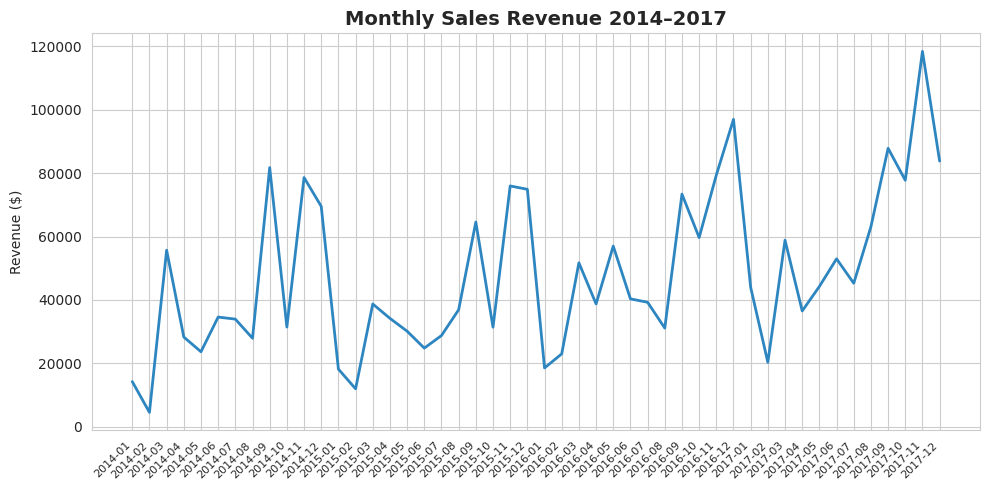

In [ ]:
# Plot 1: Monthly revenue trend
monthly = df.groupby('YearMonth')['Sales'].sum()
monthly.index = monthly.index.astype(str)
plt.figure()
plt.plot(monthly.index, monthly.values, color='#2e86c1', linewidth=2)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Monthly Sales Revenue 2014–2017', fontsize=14, fontweight='bold')
plt.ylabel('Revenue ($)'); plt.tight_layout(); plt.savefig('monthly_trend.png', dpi=150); plt.show()

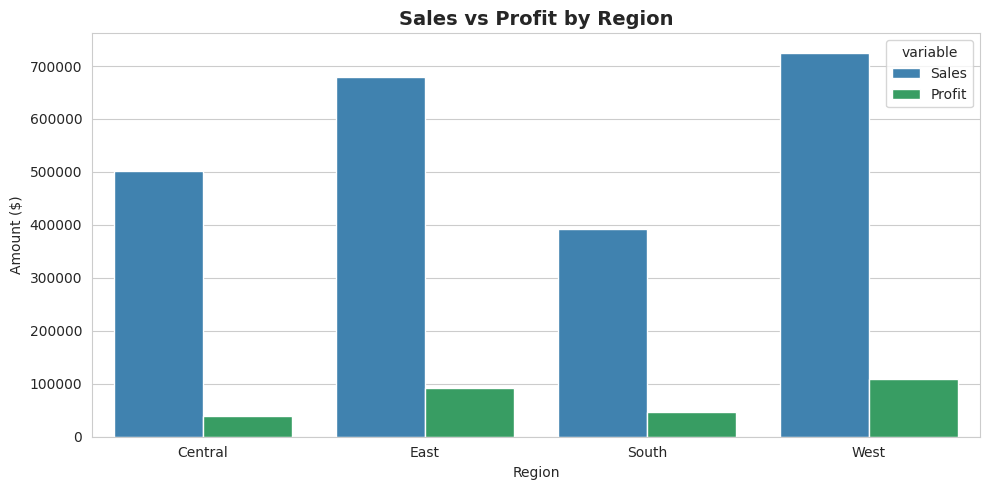

In [ ]:
# Plot 2: Sales and profit by region
region = df.groupby('Region')[['Sales','Profit']].sum().reset_index()
region_melt = region.melt(id_vars='Region', value_vars=['Sales','Profit'])
sns.barplot(data=region_melt, x='Region', y='value', hue='variable', palette=['#2e86c1','#27ae60'])
plt.title('Sales vs Profit by Region', fontsize=14, fontweight='bold')
plt.ylabel('Amount ($)'); plt.tight_layout(); plt.savefig('region.png', dpi=150); plt.show()

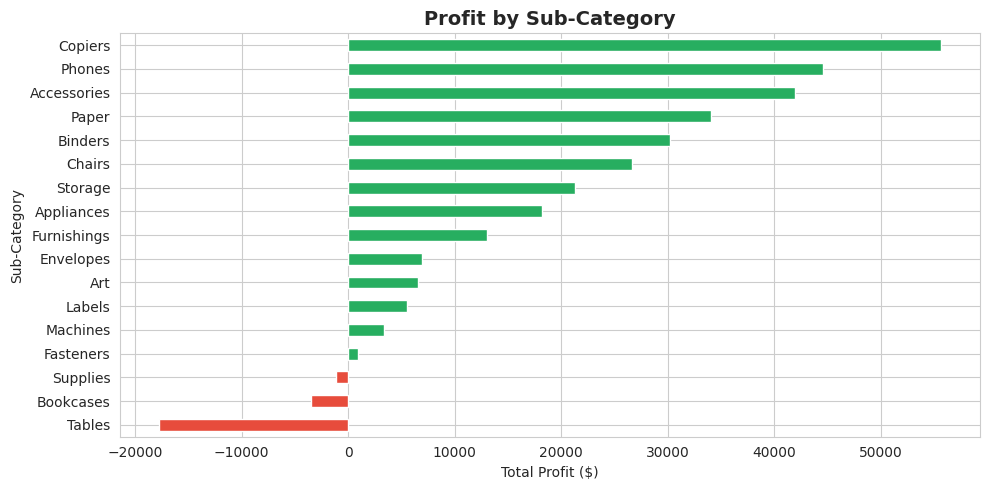

In [ ]:
# Plot 3: Profit by Sub-Category (sorted)
subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#e74c3c' if x < 0 else '#27ae60' for x in subcat.values]
subcat.plot(kind='barh', color=colors)
plt.title('Profit by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)'); plt.tight_layout(); plt.savefig('subcategory.png', dpi=150); plt.show()

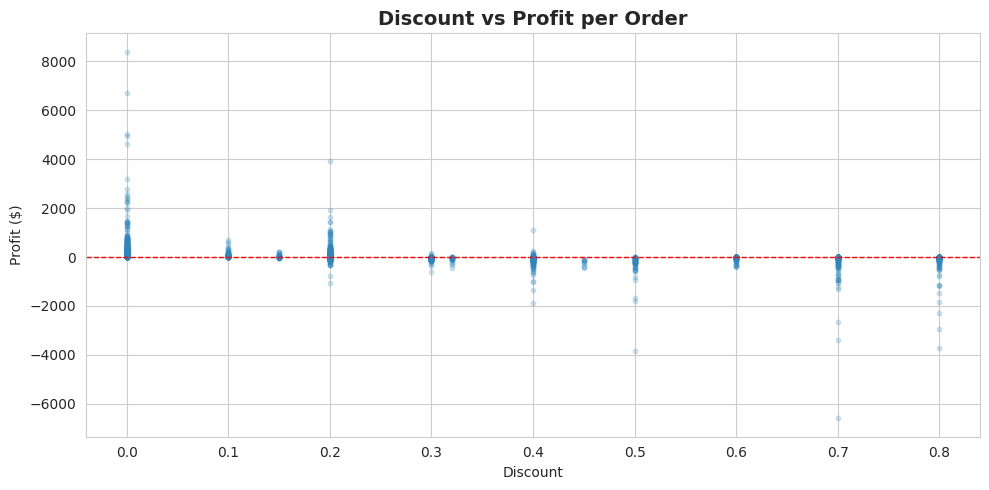

In [ ]:
# Plot 4: Discount vs Profit scatter
plt.figure()
plt.scatter(df['Discount'], df['Profit'], alpha=0.2, color='#2e86c1', s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Discount vs Profit per Order', fontsize=14, fontweight='bold')
plt.xlabel('Discount'); plt.ylabel('Profit ($)')
plt.tight_layout(); plt.savefig('discount_profit.png', dpi=150); plt.show()

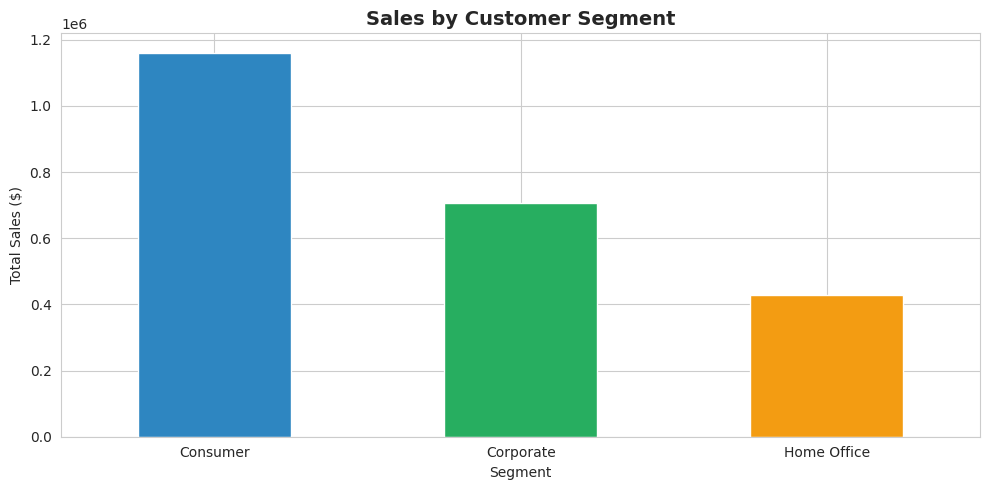

In [ ]:
# Plot 5: Sales by Segment
seg = df.groupby('Segment')['Sales'].sum()
seg.plot(kind='bar', color=['#2e86c1','#27ae60','#f39c12'], rot=0)
plt.title('Sales by Customer Segment', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)'); plt.tight_layout(); plt.savefig('segment.png', dpi=150); plt.show()

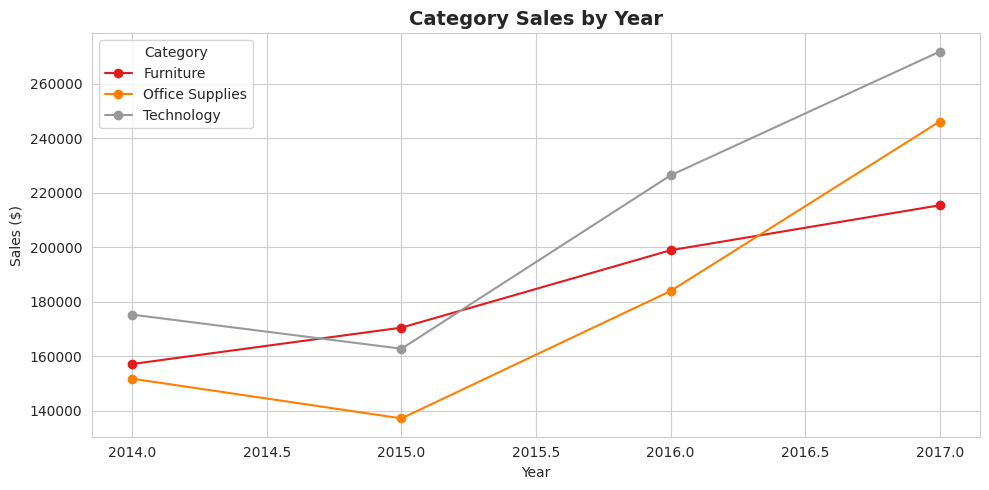

In [ ]:
# Plot 6: Category sales by year
yearly = df.groupby(['Year','Category'])['Sales'].sum().unstack()
yearly.plot(kind='line', marker='o', colormap='Set1')
plt.title('Category Sales by Year', fontsize=14, fontweight='bold')
plt.ylabel('Sales ($)'); plt.xlabel('Year')
plt.tight_layout(); plt.savefig('category_year.png', dpi=150); plt.show()